# Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
from scipy.stats import rankdata
import warnings

warnings.simplefilter('ignore')

# Load Data

In [2]:
# Load datasets
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')
submission_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv')

print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")

Train Shape: (439140, 16)
Test Shape: (188165, 15)


In [3]:
print(train.columns.tolist())
train.head(10)

['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0
5,5,D012,HARD,Saudi Arabian Grand Prix,2022,0,35,2,26.0,5,93.734,-9.878,-98.041,0.500000,-3.0,1.0
6,6,D104,MEDIUM,Belgian Grand Prix,2023,0,23,2,16.0,11,114.937,-0.181,-11.904,0.333333,0.0,0.0
7,7,D082,HARD,United States Grand Prix,2022,0,41,3,9.0,1,100.211,-10.292,-53.799,0.569444,0.0,0.0
8,8,BEL,MEDIUM,Italian Grand Prix,2022,0,4,1,4.0,12,87.973,10.745,-32.929,0.111111,-9.0,0.0
9,9,YAM,MEDIUM,Hungarian Grand Prix,2023,0,2,1,2.0,8,84.726,-6.669,-6.669,0.028169,0.0,0.0


In [4]:
def process(df):
    numeric = df.select_dtypes(include=[np.number]).columns
    df[numeric] = df[numeric].fillna(df[numeric].median())
    
    categorical = df.select_dtypes(include=['object']).columns
    df[categorical] = df[categorical].fillna('None')
    
    return df

train = process(train)
test = process(test)

# Visualizations

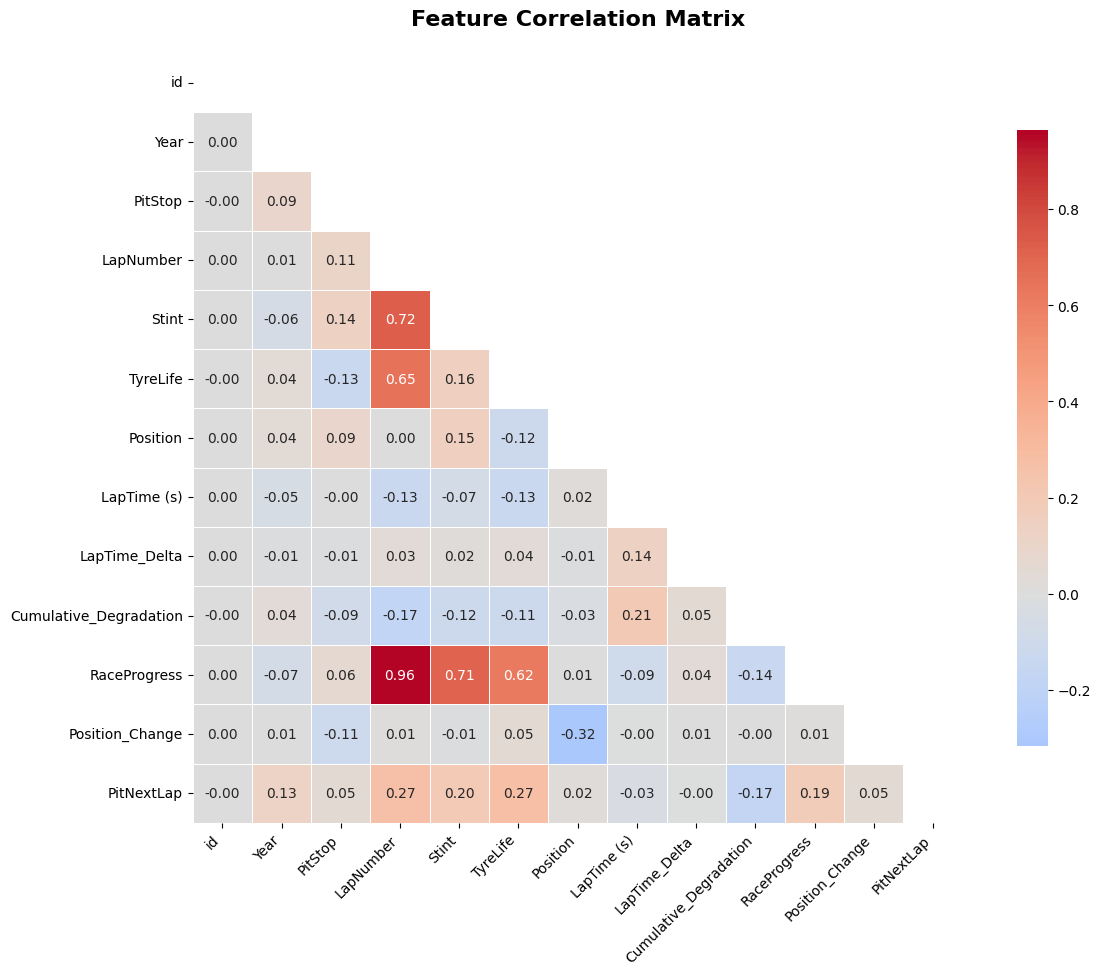

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [5]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))

corr = train.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()
plt.figure(figsize=(12, 6))

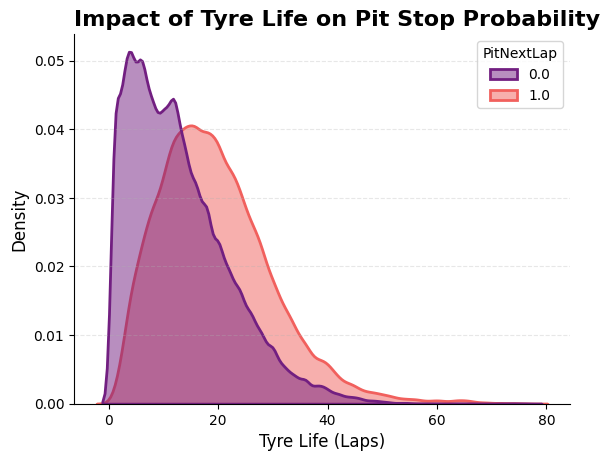

In [6]:
sns.kdeplot(
    data=train, 
    x='TyreLife', 
    hue='PitNextLap', 
    fill=True, 
    common_norm=False, 
    palette='magma', 
    alpha=.5, 
    linewidth=2
)

plt.title('Impact of Tyre Life on Pit Stop Probability', fontsize=16, fontweight='bold', loc='left')
plt.xlabel('Tyre Life (Laps)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine() 
plt.show()

# Feature Engineering

In [7]:
def process_and_engineer(train_df, test_df):
    target = 'PitNextLap'
    features = [feat for feat in test_df.columns if feat != 'id']
    cat_cols = test_df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    X = train_df[features].copy()
    y = train_df[target].copy()
    X_test = test_df[features].copy()

    for col in cat_cols:
        freq_map = X[col].value_counts(normalize=True).to_dict()
        X[f'{col}_freq'] = X[col].map(freq_map)
        X_test[f'{col}_freq'] = X_test[col].map(freq_map).fillna(0)

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[cat_cols] = encoder.fit_transform(X[cat_cols].astype(str)).astype(int)
    X_test[cat_cols] = encoder.transform(X_test[cat_cols].astype(str)).astype(int)
    
    X['Life_Ratio'] = X['TyreLife'] / (X['LapNumber'] + 1)
    X_test['Life_Ratio'] = X_test['TyreLife'] / (X_test['LapNumber'] + 1)
    
    return X, y, X_test

X, y, X_test = process_and_engineer(train, test)

# Training

In [8]:
folds = StratifiedKFold(n_splits = 10, shuffle=True, random_state=42)
oof_lgb, oof_xgb, oof_cat = [np.zeros(len(X)) for _ in range(3)]
preds_lgb, preds_xgb, preds_cat = [np.zeros(len(X_test)) for _ in range(3)]

xgb_params = {
    'n_estimators': 15000,
    'learning_rate': 0.0468,
    'max_depth': 9,
    'min_child_weight': 2,
    'subsample': 0.577,
    'colsample_bytree': 0.641,
    'gamma': 0.720,
    'tree_method': 'hist',
    'device': 'cuda' if xgb.__version__ >= '2.0' else 'gpu',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'early_stopping_rounds': 300
}

lgb_params = {
    'n_estimators': 15000,
    'learning_rate': 0.01,
    'num_leaves': 255,
    'max_depth': -1,
    'metric': 'auc',
    'verbosity': -1,
    'early_stopping_round': 300
}

for fold, (t_idx, v_idx) in enumerate(folds.split(X, y)):
    xt, xv = X.iloc[t_idx], X.iloc[v_idx]
    yt, yv = y.iloc[t_idx], y.iloc[v_idx]
    
    # XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_params)
    m_xgb.fit(xt, yt, eval_set=[(xv, yv)], verbose=False)
    oof_xgb[v_idx] = m_xgb.predict_proba(xv)[:, 1]
    preds_xgb += m_xgb.predict_proba(X_test)[:, 1] / folds.n_splits
    
    # LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_params)
    m_lgb.fit(xt, yt, eval_set=[(xv, yv)], callbacks=[lgb.early_stopping(300)])
    oof_lgb[v_idx] = m_lgb.predict_proba(xv)[:, 1]
    preds_lgb += m_lgb.predict_proba(X_test)[:, 1] / folds.n_splits
    
    print(f"Fold {fold+1} Completed")

# Blending
final_oof = (oof_lgb * 0.5) + (oof_xgb * 0.5)
final_preds = (preds_lgb * 0.5) + (preds_xgb * 0.5)

print(f"Ensemble AUC: {roc_auc_score(y, final_oof):.5f}")

Training until validation scores don't improve for 300 rounds
Fold 1 Completed
Training until validation scores don't improve for 300 rounds
Fold 2 Completed
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[1523]	valid_0's auc: 0.94883
Fold 3 Completed
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[2099]	valid_0's auc: 0.949163
Fold 4 Completed
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[1901]	valid_0's auc: 0.948908
Fold 5 Completed
Training until validation scores don't improve for 300 rounds
Fold 6 Completed
Training until validation scores don't improve for 300 rounds
Fold 7 Completed
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[1952]	valid_0's auc: 0.949128
Fold 8 Completed
Training until validation scores don't improve for 300 rounds
Fold 9 Completed
Training until validation 

In [9]:
final_preds_weighted = (preds_lgb * 0.4) + (preds_xgb * 0.3) + (preds_cat * 0.3)

rank_preds = (
    rankdata(preds_lgb) * 0.4 + 
    rankdata(preds_xgb) * 0.3 + 
    rankdata(preds_cat) * 0.3
)
final_preds_ranked = rank_preds / (len(rank_preds) + 1)

print(f"Weighted Mean Sample: {final_preds_weighted[:5]}")
print(f"Rank-Averaged Sample: {final_preds_ranked[:5]}")

Weighted Mean Sample: [0.0023272  0.00335627 0.00177682 0.1558688  0.62016292]
Rank-Averaged Sample: [0.32400487 0.36193255 0.29458935 0.64906572 0.82440133]


# Submission

In [10]:
submission = pd.DataFrame({
    'id': test['id'],
    'PitNextLap': rankdata(final_preds) / (len(final_preds) + 1)
})

submission.to_csv('submission.csv', index=False)